In [1]:
import torchvision
import numpy as np
import random

import torch
import torch.nn.functional as F
import cl_gym as cl

import sys
import os

seed = 0

init_path = os.path.abspath('.')
new_path = init_path
while True:
    if new_path[-3:] == "FSW":
        sys.path.append(new_path)
        break
    new_path = os.path.abspath('..')
    os.chdir(new_path)

np.random.seed(seed)
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.cuda.manual_seed_all(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.enabled = False
torch.set_num_threads(4)

def make_params() -> dict:
    import os
    from pathlib import Path
    import uuid

    params = {
            'debug': True,

            # dataset
            'dataset': "Drug",
            'fairness_agg': 'mean',
            # 'model': 'MLP',

            # benchmark
            'seed': seed,
            'num_tasks': 3,
            'epochs_per_task': 25,
            'per_task_examples': np.inf,
            # 'per_task_examples': 2000,
            'per_task_memory_examples': 64,
            'batch_size_train': 64,
            'batch_size_memory': 64,
            'batch_size_validation': 256,
            'tau': 1.0,

            # algorithm
            'optimizer': 'sgd',
            'learning_rate': 0.001,
            'momentum': 0.9,
            'learning_rate_decay': 1.0,
            'criterion': torch.nn.CrossEntropyLoss(),
            # 'criterion': torch.nn.BCEWithLogitsLoss(),

            'device': torch.device('cuda:7' if torch.cuda.is_available() else 'cpu'),
             
            # sample selection
            'alpha': 0.002,
            'metric' : "EO",
            'lambda': 0.1,
            'lambda_old': 0.0,

            # postprocessing
            # "post_processing": "eps_fairness"

              }
    

#     trial_id = str(uuid.uuid4())
    trial_id = f"demo/dataset={params['dataset']}/seed={params['seed']}_epoch={params['epochs_per_task']}_lr={params['learning_rate']}_tau={params['tau']}_alpha={params['alpha']}"
    if params['lambda'] != 0:
        trial_id+=f"_lmbd_{params['lambda']}_lmbdold_{params['lambda_old']}"
    params['trial_id'] = trial_id
    params['output_dir'] = os.path.join("./outputs/{}".format(trial_id))
    print(f"output_dir={params['output_dir']}")
    Path(params['output_dir']).mkdir(parents=True, exist_ok=True)

    return params

params = make_params()

output_dir=./outputs/demo/dataset=Drug/seed=0_epoch=25_lr=0.001_tau=1.0_alpha=0.002_lmbd_0.1_lmbdold_0.0


In [2]:
"MNIST" in params['dataset']

False

In [3]:
from datasets import Drug

if params['dataset'] in ["Drug"]:
    benchmark = Drug(num_tasks=params['num_tasks'],
                        per_task_memory_examples=params['per_task_memory_examples'],
                        per_task_examples = params['per_task_examples'],
                        random_class_idx = False)
    input_dim = (12)
    class_idx = benchmark.class_idx
    num_classes = len(class_idx)

In [4]:
from trainers import FairContinualTrainer
from trainers.fair_trainer import FairContinualTrainer2
from metrics import FairMetricCollector
from metrics import MetricCollector2

from algorithms import Heuristic3
from algorithms.fairl import FaIRL
from algorithms.icarl import iCaRL
from backbones import MLP2Layers2

backbone = MLP2Layers2(
    input_dim=input_dim, 
    hidden_dim_1=256, 
    hidden_dim_2=256, 
    output_dim=num_classes,
    class_idx=class_idx,
    config=params
    ).to(params['device'])

algorithm = Heuristic3(backbone, benchmark, params, requires_memory=True)

metric_manager_callback = FairMetricCollector(num_tasks=params['num_tasks'],
                                                        eval_interval='epoch',
                                                        epochs_per_task=params['epochs_per_task'])
# metric_manager_callback = MetricCollector2(num_tasks=params['num_tasks'],
#                                                         eval_interval='epoch',
#                                                         epochs_per_task=params['epochs_per_task'])
# from trainers.baselines import BaseMemoryContinualTrainer as ContinualTrainer
from trainers.fair_trainer import FairContinualTrainer2 as ContinualTrainer

trainer = ContinualTrainer(algorithm, params, callbacks=[metric_manager_callback])
# 
# trainer = FairContinualTrainer2(algorithm, params, callbacks=[metric_manager_callback])


In [5]:
if params['fairness_agg'] == "mean":
    agg = np.mean
elif params['fairness_agg'] == "max":
    agg = np.max
else:
    raise NotImplementedError

fairness_metrics = ["std", "EER", "EO", "DP"]
for metric in metric_manager_callback.meters:
    if metric in fairness_metrics:
        metric_manager_callback.meters[metric].agg = agg


In [6]:
from algorithms.optimization import absolute_and_nonabsolute_minsum_LP_solver
solver = absolute_and_nonabsolute_minsum_LP_solver
converter = algorithm.converter_LP_absolute_additional_EO_v2

params['solver'] = solver
params['converter'] = converter

In [7]:
if params['fairness_agg'] == "mean":
    agg = np.mean
elif params['fairness_agg'] == "max":
    agg = np.max
else:
    raise NotImplementedError

fairness_metrics = ["std", "EER", "EO", "DP"]
for metric in metric_manager_callback.meters:
    if metric in fairness_metrics:
        metric_manager_callback.meters[metric].agg = agg


In [8]:
trainer.run()
print("final avg-acc", metric_manager_callback.meters['accuracy'].compute_final())
print("final avg-forget", metric_manager_callback.meters['forgetting'].compute_final())

---------------------------- Task 1 -----------------------
[1] Eval metrics for task 1 >> {'accuracy': 0.056910569105691054, 'loss': 0.009496929719276036, 'std': 0.056910569105691054, 'EER': -1, 'EO': [0.08383458646616541, 0.0], 'DP': -1, 'accuracy_s0': 0.08928571428571429, 'accuracy_s1': 0.04736842105263158, 'classwise_accuracy': {0: array([ 14, 123]), 1: array([ 0, 71])}, 'DP_ingredients': {'class_pred_count_s0': {5: 37, 0: 13, 2: 11, 3: 1}, 'class_pred_count_s1': {5: 63, 3: 27, 0: 15, 2: 27}, 'class_pred_count': {5: 100, 3: 28, 0: 28, 2: 38}, 'count_s0': 62, 'count_s1': 132, 'count': 194}}
[2] Eval metrics for task 1 >> {'accuracy': 0.483739837398374, 'loss': 0.008856236934661865, 'std': 0.483739837398374, 'EER': -1, 'EO': [0.04210526315789476, 0.0], 'DP': -1, 'accuracy_s0': 0.5, 'accuracy_s1': 0.4789473684210526, 'classwise_accuracy': {0: array([119, 123]), 1: array([ 0, 71])}, 'DP_ingredients': {'class_pred_count_s0': {0: 61, 5: 1}, 'class_pred_count_s1': {0: 126, 2: 3, 5: 3}, 'c

In [18]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['pdf.fonttype'] = 42    
plt.rc('font', size=25)
plt.rc('axes', labelsize=25)
plt.rc('xtick', labelsize=25)
plt.rc('ytick', labelsize=25)
plt.rc('legend', fontsize=25)
plt.rc('figure', titlesize=25)

def draw_plot_loss(eo, ce_eo, title, eo_range=None, ce_eo_range=None):
    num_epochs = len(eo)
    fig = plt.figure(figsize=(15, 6))
    if title is not None or len(title)>0:
        fig.suptitle(title)
    ax1 = fig.add_subplot()
    ax1.grid(False)

    ax1.set_xticks(np.arange(0, num_epochs+1, 15), [])
    ax1.set_xlim(0, 75)
    ax1.set_ylim(0, 0.2)

    lns1 = ax1.plot(np.arange(1, num_epochs+1), eo, color = "blue", label="EO Disparity")
    ax1.set_ylabel("EO Disparity")

    ax2 = ax1.twinx()
    ax2.grid(False)
    lns2 = ax2.plot(np.arange(1, num_epochs+1), ce_eo, color = "orange", label="Cost function for EO")
    ax2.set_ylabel("Cost function for EO")
    ax2.set_ylim(0, 1.6)

    # Change the color of the axis to black
    ax1.tick_params(colors='black')
    ax2.tick_params(colors='black')
    ax1.spines['bottom'].set_color('black')
    ax1.spines['top'].set_color('black') 
    ax1.spines['right'].set_color('black')
    ax1.spines['left'].set_color('black')

    ax2.spines['bottom'].set_color('black')
    ax2.spines['top'].set_color('black') 
    ax2.spines['right'].set_color('black')
    ax2.spines['left'].set_color('black')

    plt.axvline(x=25, color = "black", linewidth=1.5, linestyle="dashed")
    plt.axvline(x=50, color = "black", linewidth=1.5, linestyle="dashed")

    plt.text(12.5, -0.18, 'Task 1', ha='center', va='bottom', fontsize=30)
    plt.text(37.5, -0.18, 'Task 2', ha='center', va='bottom', fontsize=30)
    plt.text(62.5, -0.18, 'Task 3', ha='center', va='bottom', fontsize=30)


    # ax1.set_xlabel('epochs')
    lns = lns1 + lns2
    labs = [l.get_label() for l in lns]

    # ax1.legend(lns, labs, loc='upper right',)
    ax1.legend(lns, labs, bbox_to_anchor=(0., 1.05, 1., .1), loc='center',
            ncol=10, borderaxespad=0.)

    plt.savefig(f"output.pdf", bbox_inches="tight")
    plt.show()



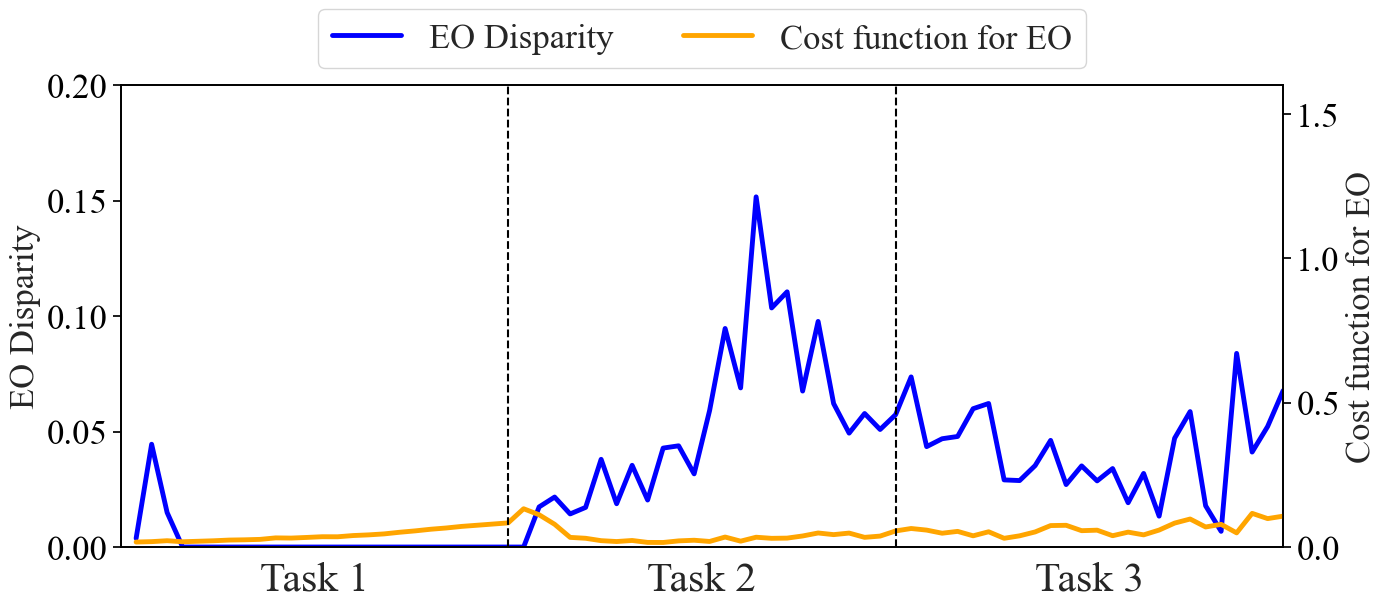

In [19]:
num_epochs = params['epochs_per_task']
num_tasks = params['num_tasks']

title = f""
draw_plot_loss([np.mean(x) for x in algorithm.disp], [np.mean(x) for x in algorithm.CELoss_disp], title, eo_range=None, ce_eo_range=None)